# Filter search for envelope extraction

Determining the appropriate filter band for envelope analysis is crucial because fault-induced impacts excite specific resonance frequencies where modulation effects are most pronounced. An incorrectly selected filter may attenuate the fault-related information or introduce unrelated vibration components, reducing the detectability of bearing and gear defects.

Different machine faults generate modulation at different characteristic frequencies, such as bearing defect frequencies (BPFO, BPFI, BSF, FTF) or gear mesh sidebands. Therefore, the filter band must be carefully chosen to capture the resonance region that best demodulates the relevant modulation frequencies and maximizes the signal-to-noise ratio of the extracted envelope spectrum.

To simplify the the filter selection, a method `filter_search_for_envelope_extraction` can be used. It tests multiple different filters in a optimised way.

**! Important**, measurement where the filter search will be performed must be from the damaged bearing.

First let's open the measurement.

In [1]:
import pickle

with open("data/measurement.pkl", "rb") as f:
    data = pickle.load(f)

t = data["t"]
force = data["force"]

And define the bearing matching the measurement.

In [2]:
from pybearing.data.bearing_database import BearingDatabase
database = BearingDatabase()
characteristic_frequencies = database.find_characteristic_frequencies_by_bearing_name("NMB_1560kk")[0]

Method `filter_search_for_envelope_analysis` is implemented inside the `envelope_analysis` module.

The method requires multiple arguments, which can influence the search range and score calculation:
- x: raw measurement that search for filter will be performed on.
- fs: sampling frequency in Hz.
- fault_frequencies: bearing fault frequencies. Should be calculated for the same frequency that the bearing is rotating in the raw measurement.
- max_level: depth of search -> higher level, more filter bands will be tested.
- compute_triadic: increase number of bands even more, adds more combinations.
- max_frequency: maximum high filter frequency -> limit search.
- min_frequency: minimum low filter frequency -> limit search.
- epsilon: if min_frequency and max_frequency are not set, min_frequency is calculated as epsilon * fs and max_frequency as fs / 2 - epsilon * fs.
- calculate_harmonics_score: calculate score for filter selection. It is calculated by the following equation:

$\text{score}_\text{characteristic fault} = \frac{RMS_\text{fault harmonics}}{RMS_\text{rest of spectrum}} \cdot ln(1 + RMS_\text{fault harmonics})$

To determine bandwidth for calculation or RMS around fault harmonics, next parameters needs to be set:

- n_harmonics: number of harmonics included in the RMS calculation.
- min_samples: minimum number of samples to calculate RMS.
- absolute_error: absolute error of harmonic calculation.
- relative_error: relative error of harmonic calculation.

Bandwidth is then defined as:

$max\left(\text{absolute error}, \text{relative error}\cdot \text{target frequency}, \text{min samples} \cdot \Delta f\right)$, where $\Delta f$ is the frequency resolution, determined by the measurement length.

- calculate_kurtosis_score: calculate kurtosis for selected filter.

In [3]:
from pybearing.analysis.envelope_analysis import filter_search_for_envelope_extraction

target_frequency = 5.1
frequencies = characteristic_frequencies * target_frequency

results = filter_search_for_envelope_extraction(x=force, 
                                                fs=6400,
                                                fault_frequencies=frequencies, 
                                                max_level=6,
                                                compute_triadic=True, 
                                                max_frequency=3000,
                                                min_frequency=20,
                                                epsilon=1e-4,
                                                calculate_harmonics_score=True,
                                                n_harmonics=3,
                                                min_samples=2, 
                                                absolute_error=0.5,
                                                relative_error=0.04,
                                                calculate_kurtosis_score=False)

After obtaining results, plots for each score can be made using the `plot_filter_serach_for_envelope_extraction` method. Based on the plots it is possible to determine best filter band for envelope extraction, but the filter band should also be tested and envelope spectrum visually inspected to be sure that the filter is optimal. It is also possible that different filters should be used for proper identification of different faults.

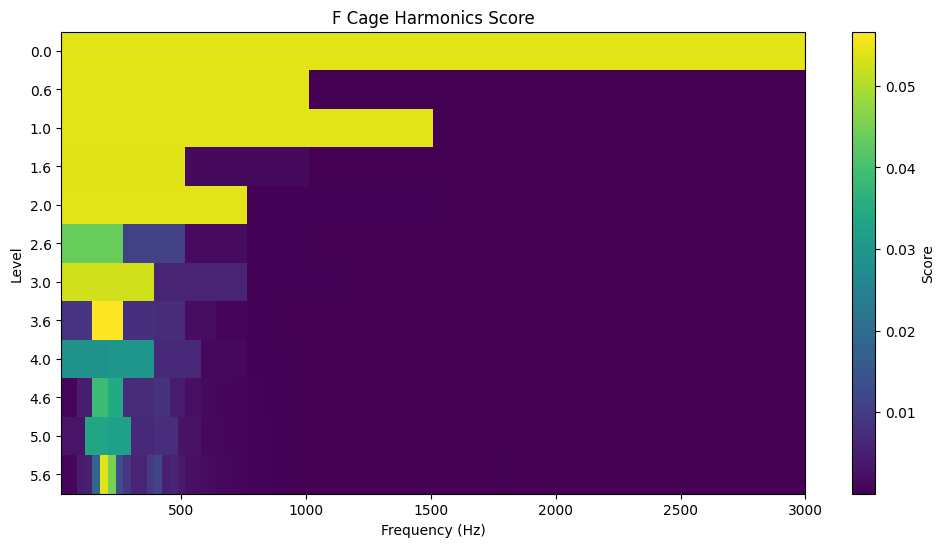

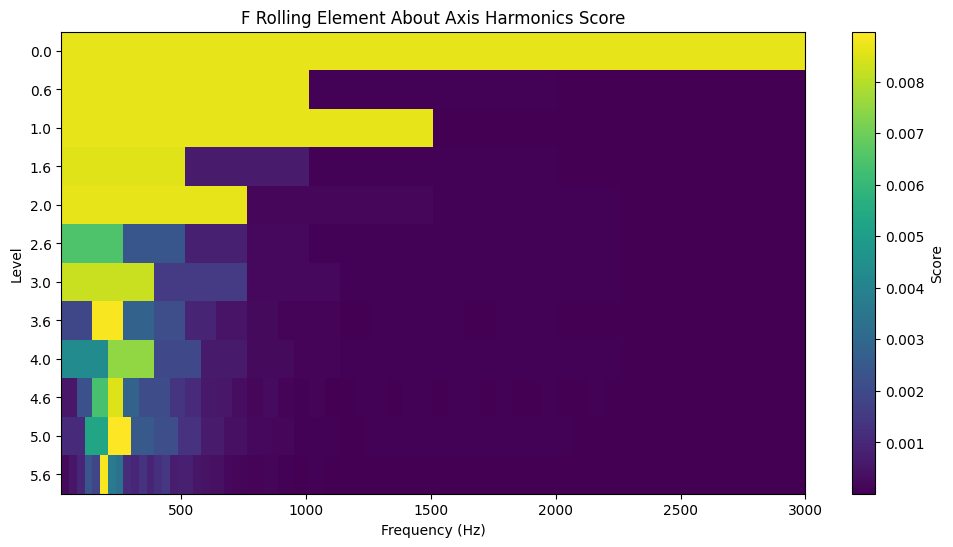

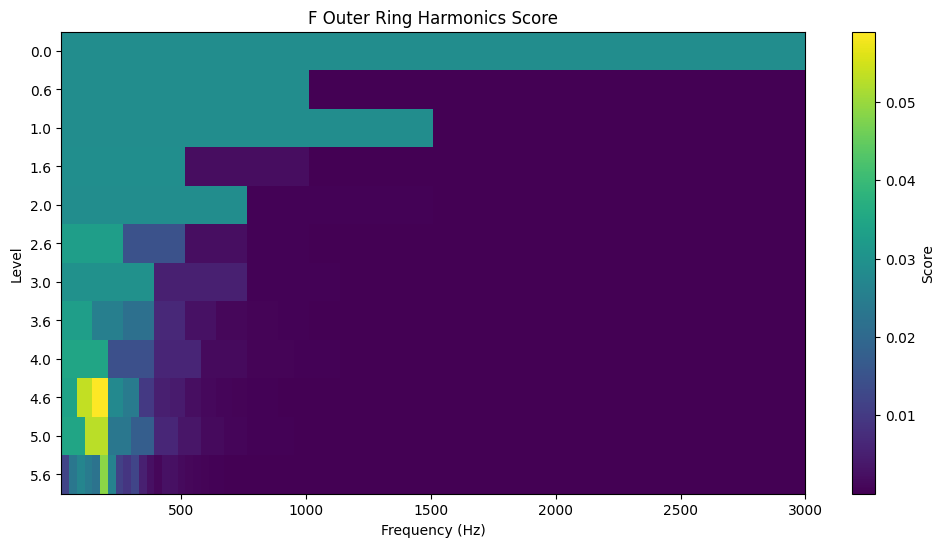

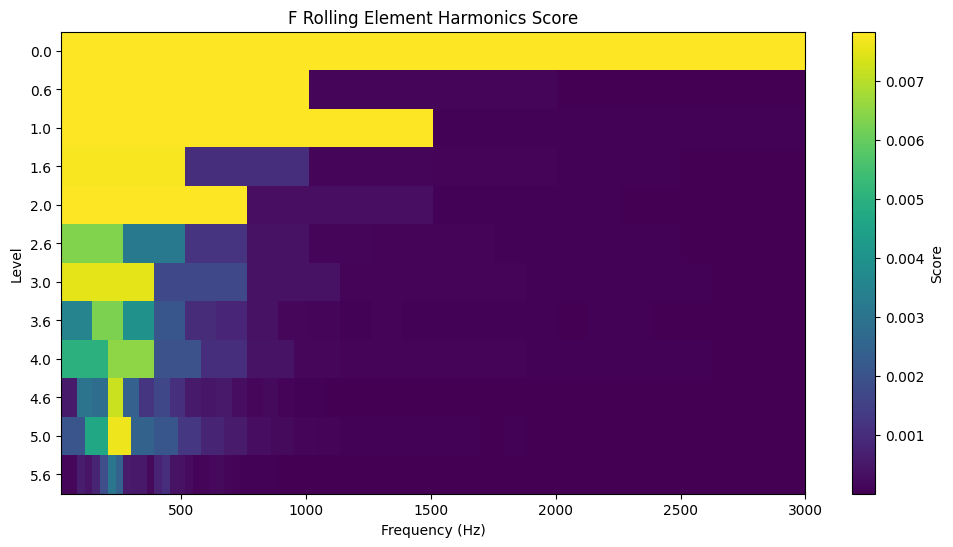

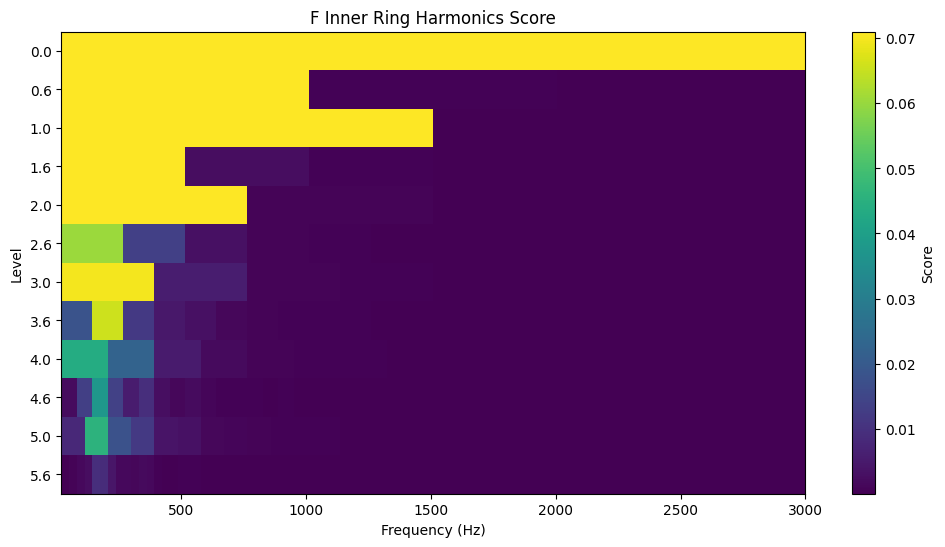

In [4]:
from pybearing.visualization.envelope_analysis import plot_filter_search_for_envelope_extraction

plot_filter_search_for_envelope_extraction(results,
                                           plot_harmonics_score=True,
                                           plot_kurtosis_score=False)